In [2]:
# importamos las librerias necesarias y el df que hemos limpiado previamente para analizar los precios en la temporada anterior (2025).
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("../../src/data/df_2025_limpio.csv")

## **HIPÓTESIS 1**

Los alojamientos ubicados en el Centro tienen precios más altos que los alojamientos del resto de barrios.

**JUSTIFICACIÓN DE LA HIPÓTESIS**

El Centro concentra la mayor parte de la oferta (6389 alojamientos) un 67% del df, es la zona más turística y suele tener mayor demanda, 
lo que razonablemente podría elevar los precios.

**PLAN DE ACCIÓN**

*Si la hipótesis se confirma:*

 - Analizaremos qué factores dentro del Centro explican ese precio más alto:

       - tipo de habitación (room_type)

       - número de reseñas (number_of_reviews)

       - disponibilidad anual (availability_365)

Compararemos el Centro con los dos siguientes barrios más relevantes (Este y Carretera de Cádiz) para ver si la diferencia es estructural 
o puntual.

*Si la hipótesis no se confirma:*

 - Analizaremos cuales son los factores que más influyen en el precio medio:

       - Tipo de habitación (room_type)

       - Número de reseñas (number_of_reviews)

       - Disponibilidad anual (availability_365)  


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6861 entries, 0 to 6860
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            6861 non-null   str    
 1   host_id                         6861 non-null   int64  
 2   host_name                       6861 non-null   str    
 3   neighbourhood                   6861 non-null   str    
 4   room_type                       6861 non-null   str    
 5   price                           6861 non-null   float64
 6   minimum_nights                  6861 non-null   int64  
 7   number_of_reviews               6861 non-null   int64  
 8   last_review                     6861 non-null   str    
 9   reviews_per_month               6861 non-null   float64
 10  calculated_host_listings_count  6861 non-null   int64  
 11  availability_365                6861 non-null   int64  
 12  number_of_reviews_ltm           6861 non-null

In [4]:
# vamos a analizar el precio medio por barrio
df.groupby("neighbourhood")["price"].mean().sort_values(ascending=False)

neighbourhood
Campanillas             2989.210526
Churriana                594.290909
Puerto de la Torre       444.931034
Este                     310.222061
Teatinos-Universidad     284.127660
Cruz De Humilladero      255.663265
Carretera de Cadiz       251.097598
Centro                   157.234670
Palma-Palmilla           141.650407
Ciudad Jardin            113.134615
Bailen-Miraflores         73.589862
Name: price, dtype: float64

In [ ]:
# Sorprendentemente, algunos barrios presentan precios medios muy por encima del promedio general. Para entender si estos valores se deben a 
# alojamientos con precios desorbitados que distorsionan la media de forma desproporcionada, vamos a analizar los outliers del DataFrame 
# completo.
# El objetivo es identificar si existen precios anómalamente altos que estén influyendo en la interpretación global del mercado.

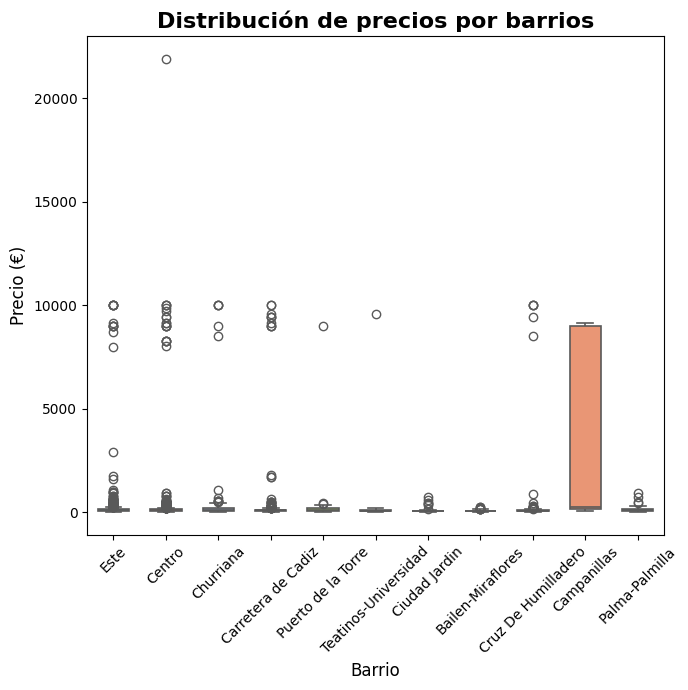

In [5]:
# Diagrama de cajas entre variable categórica (barrio) y precios.
plt.figure(figsize = (7,7))

sns.boxplot(
    x="neighbourhood",
    y="price",
    hue="neighbourhood",
    data=df,
    palette="Set2",
    legend=False,
    linewidth=1.2,
    width=0.6
)

plt.title("Distribución de precios por barrios",
          fontsize=16, weight="bold")

plt.xlabel("Barrio", fontsize = 12)
plt.ylabel("Precio (€)", fontsize = 12)

plt.xticks(rotation=45) # Para que sea mas legible

plt.tight_layout()
plt.show()

In [6]:
# En este caso nos llama especialmente la atención el barrio de Campanillas, ya que presenta un precio medio notablemente superior al del resto
# de la ciudad, pese a mostrar una aparente estabilidad interna.
# 
# Para comprender si este comportamiento se debe a valores atípicos que estén inflando la media, vamos a analizar Campanillas de forma individual.

df_campanillas = df[df["neighbourhood"]=="Campanillas"]
df_campanillas.info()


<class 'pandas.DataFrame'>
Index: 19 entries, 444 to 6853
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            19 non-null     str    
 1   host_id                         19 non-null     int64  
 2   host_name                       19 non-null     str    
 3   neighbourhood                   19 non-null     str    
 4   room_type                       19 non-null     str    
 5   price                           19 non-null     float64
 6   minimum_nights                  19 non-null     int64  
 7   number_of_reviews               19 non-null     int64  
 8   last_review                     19 non-null     str    
 9   reviews_per_month               19 non-null     float64
 10  calculated_host_listings_count  19 non-null     int64  
 11  availability_365                19 non-null     int64  
 12  number_of_reviews_ltm           19 non-null     in

In [7]:
df_campanillas["price"].describe()

count      19.000000
mean     2989.210526
std      4213.307682
min        56.000000
25%       157.500000
50%       259.000000
75%      9000.000000
max      9143.000000
Name: price, dtype: float64

In [ ]:
# El barrio de Campanillas cuenta con un total de 19 alojamientos, lo que representa únicamente el 0,27 % del DataFrame completo.
# A pesar de su reducido tamaño, presenta un precio medio de 2.989 €, mientras que la mediana es de solo 259 €, lo que evidencia una fuerte 
# asimetría en la distribución.
# 
# Además, el precio máximo alcanza los 9.143 € y el Q3 supera los 9.000 €, valores extremadamente altos que actúan como outliers y distorsionan 
# de manera significativa la media del barrio.

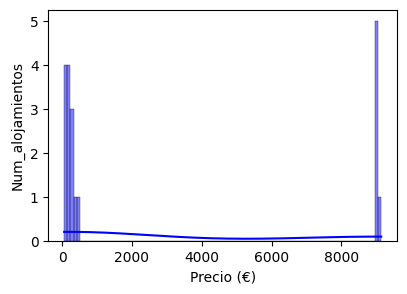

In [9]:
# HISTOGRAMA Y KDE - "Campanillas"

fig, axs = plt.subplots(1,1,figsize= (4.5,3))

sns.histplot(
    df_campanillas["price"],
    kde=True,
    color="b",
    bins=100,
    ax = axs
)
axs.set_xlabel("Precio (€)")
axs.set_ylabel("Num_alojamientos");

In [ ]:
# Vamos a comprobar cuales son todos los valores extremos del df.

umbral_extremo = df["price"].quantile(0.99)

df_outliers_extremos = df[df["price"] > umbral_extremo]

df_outliers_extremos["price"].describe()



count       69.000000
mean      8340.826087
std       3243.765708
min       1000.000000
25%       8500.000000
50%       9000.000000
75%       9858.000000
max      21911.000000
Name: price, dtype: float64

In [11]:
# Hay un total de 69 alojamientos los cuales tienen un precio muy por encima de la media. Este grupo representa el 1% de los alojamientos del 
# df, con precios que van desde 1.000 € hasta 21.911 €. Dado que su peso estadístico es muy reducido y sus precios no reflejan el comportamiento 
# real del mercado, procederemos a eliminarlos del análisis. De este modo obtenemos una visión más coherente y representativa del mercado de 
# alojamientos en Málaga.

df["es_outlier"] = df["price"] > umbral_extremo

df_limpio = df[df["es_outlier"] == False]

In [ ]:
# Una vez identificados y eliminados estos valores extremos, podemos continuar con el análisis de forma más precisa.  
# Al depurar el dataset de precios atípicos, obtenemos una visión más fiel del comportamiento real del mercado y evitamos que unos pocos 
# alojamientos desproporcionadamente caros distorsionen las conclusiones del estudio.  
# A partir de aquí recalcularemos las métricas por barrio y volveremos a evaluar la Hipótesis 1 con datos más representativos.

In [12]:
df_limpio.groupby("neighbourhood")["price"].mean().sort_values(ascending=False)

neighbourhood
Campanillas             204.000000
Churriana               161.298077
Palma-Palmilla          141.650407
Puerto de la Torre      139.392857
Este                    137.897168
Centro                  117.459095
Ciudad Jardin           113.134615
Carretera de Cadiz      104.079632
Cruz De Humilladero      94.245675
Teatinos-Universidad     82.217391
Bailen-Miraflores        73.589862
Name: price, dtype: float64

<Figure size 1000x500 with 0 Axes>

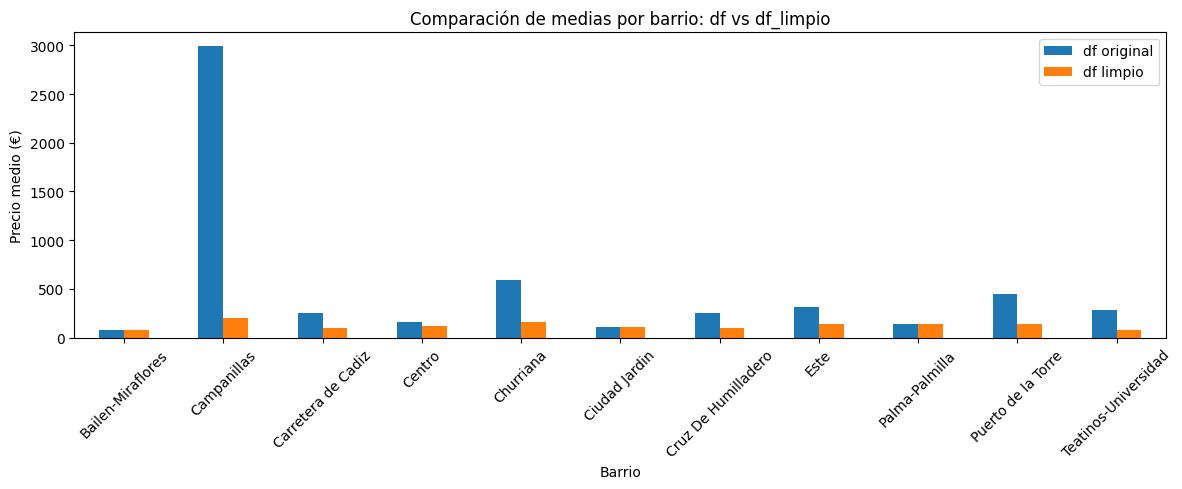

In [13]:
# En este gráfico analizamos cómo se modifican los precios medios por barrio antes y después de eliminar los outliers.  
# El objetivo es comprobar hasta qué punto los valores extremos estaban distorsionando la media y si, una vez depurados, la comparación entre 
# barrios resulta más coherente y representativa del mercado real.

# Medias por barrio en df original
media_df = df.groupby("neighbourhood")["price"].mean()

# Medias por barrio en df limpio
media_df_limpio = df_limpio.groupby("neighbourhood")["price"].mean()

# Unimos ambas series en un solo DataFrame
comparacion = pd.DataFrame({
    "Media_df_original": media_df,
    "Media_df_limpio": media_df_limpio
})

# Gráfico
plt.figure(figsize=(10,5))
comparacion.plot(kind="bar", figsize=(12,5))

plt.title("Comparación de medias por barrio: df vs df_limpio")
plt.ylabel("Precio medio (€)")
plt.xlabel("Barrio")
plt.xticks(rotation=45)
plt.legend(["df original", "df limpio"])

plt.tight_layout()
plt.show();

In [ ]:
# La comparación muestra que la mayoría de los barrios apenas sufren cambios significativos, lo que indica que sus precios son relativamente 
# estables.  Sin embargo, en Campanillas la media cae de forma drástica, confirmando que su aparente precio elevado se debía casi exclusivamente
#  a unos pocos alojamientos con valores extremadamente altos.  
# Tras la eliminación de esos outliers, la distribución de precios por barrio resulta mucho más coherente y representativa.
# Con esta visión, observamos que la hipótesis 1 queda refutada, comprobando que el "Centro", no es el barrio más caro de Málaga.
# Dado que el precio medio no parace depender únicamente de la localización, continuaremos analizando qué otros factores pueden influir en el
# precio medio, ya sea por tipo de alojamiento, el número de reseñas o la disponibilidad anual.

In [ ]:
# A continuación analizamos la correlación entre el precio y otras variables potencialmente influyentes, como el tipo de alojamiento, el número
# de reseñas o la disponibilidad anual.  
# El objetivo es identificar qué factores tienen una relación más fuerte con el precio y cuáles apenas influyen.

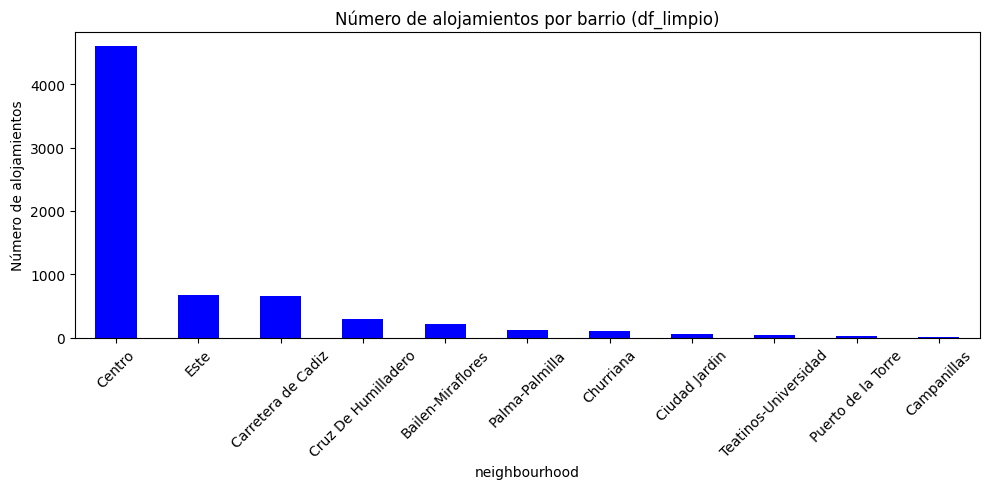

In [14]:
# Vamos a calcular cuántos alojamientos hay en cada barrio para entender cómo se distribuye la oferta dentro del conjunto completo de datos.

conteo_barrio = df_limpio["neighbourhood"].value_counts()

plt.figure(figsize=(10,5))
conteo_barrio.plot(kind="bar", color="b")

plt.title("Número de alojamientos por barrio (df_limpio)")
plt.ylabel("Número de alojamientos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
df['neighbourhood'].value_counts(normalize=True) * 100


neighbourhood
Centro                  67.264247
Este                    10.042268
Carretera de Cadiz       9.707040
Cruz De Humilladero      4.285090
Bailen-Miraflores        3.162804
Palma-Palmilla           1.792742
Churriana                1.603265
Ciudad Jardin            0.757907
Teatinos-Universidad     0.685031
Puerto de la Torre       0.422679
Campanillas              0.276928
Name: proportion, dtype: float64

                      price  number_of_reviews  availability_365
price              1.000000          -0.103457          0.044779
number_of_reviews -0.103457           1.000000         -0.097518
availability_365   0.044779          -0.097518          1.000000


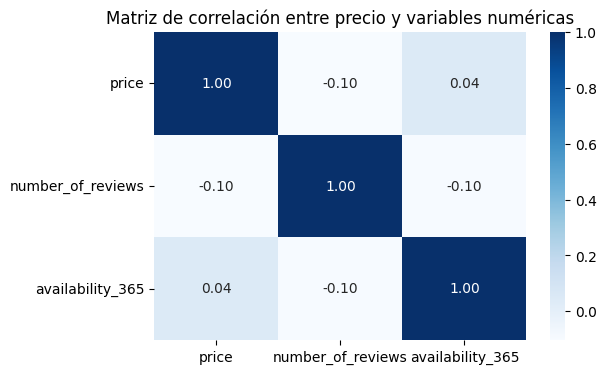

In [17]:
correlaciones = df_limpio[["price", "number_of_reviews", "availability_365"]].corr()
print(correlaciones)

# Vamos a generar un mapa de calor para verlo de forma mas visual
plt.figure(figsize=(6,4))
sns.heatmap(correlaciones, annot=True, cmap="Blues", fmt=".2f")
plt.title("Matriz de correlación entre precio y variables numéricas")
plt.show()

In [ ]:
# La matriz de correlación muestra que no existe ninguna relación fuerte entre el precio y las variables numéricas analizadas.  

# La correlación entre precio y número de reseñas es ligeramente negativa, lo que sugiere que los alojamientos más económicos tienden a 
# alquilarse con mayor frecuencia y, por tanto, acumulan más reseñas.  

# Por otro lado, la disponibilidad anual apenas presenta relación con el precio, indicando que no es un factor determinante en su variación.
# 
# En conjunto, estos resultados confirman que el precio no depende de forma directa ni del volumen de reseñas ni de la disponibilidad.  
# 
# Será necesario explorar otras variables como el tipo de alojamiento para entender mejor qué factores influyen realmente en el precio medio.

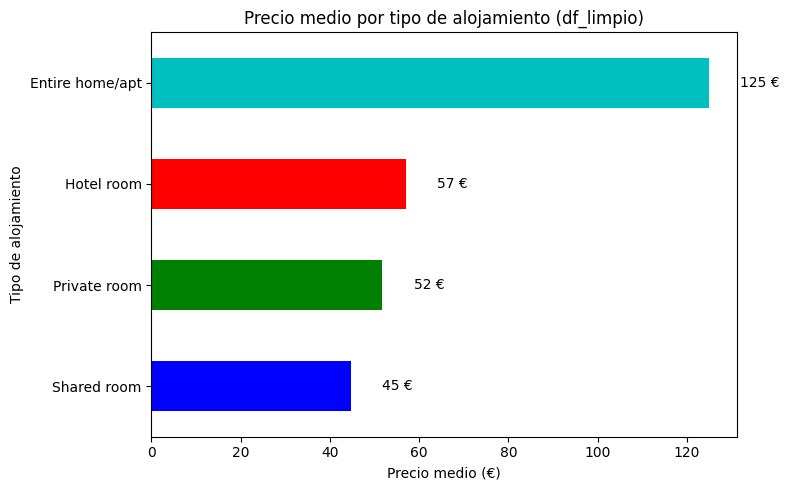

In [23]:
media_room = df_limpio.groupby("room_type")["price"].mean().sort_values()

plt.figure(figsize=(8,5))
media_room.plot(
    kind="barh",
    color=["b", "g", "r", "c"]
)
# Etiquetas encima de cada barra
for i, valor in enumerate(media_room):
    plt.text(valor + 7, i, f"{valor:.0f} €", va='center')


plt.title("Precio medio por tipo de alojamiento (df_limpio)")
plt.xlabel("Precio medio (€)")
plt.ylabel("Tipo de alojamiento")
plt.tight_layout()
plt.show()

In [ ]:
# El análisis del precio medio por tipo de alojamiento muestra diferencias claras entre categorías.  Los alojamientos de tipo *Entire home/apt* 
# son, con diferencia, los más caros, lo que resulta coherente al tratarse de viviendas completas con mayor privacidad y capacidad.

# Les siguen los *Hotel room*, con un precio medio intermedio, mientras que las *Private room* presentan valores notablemente más bajos.  
# Finalmente, las *Shared room* son la opción más económica del mercado.

# Por tanto, el tipo de alojamiento es uno de los principales elementos explicativos del precio medio en Málaga.

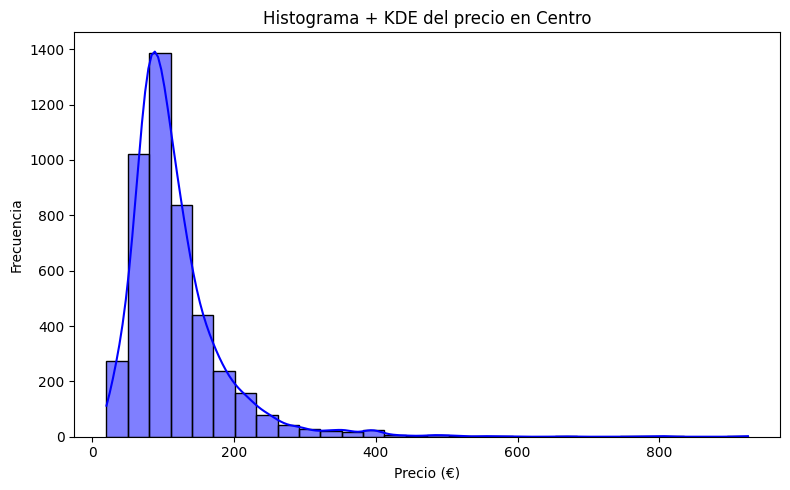

In [19]:
df_centro = df_limpio[df_limpio["neighbourhood"] == "Centro"]

plt.figure(figsize=(8,5))

sns.histplot(
    data=df_centro,
    x="price",
    bins=30,
    kde=True,
    color="b",        # azul normal
    edgecolor="black"
)

plt.title("Histograma + KDE del precio en Centro")
plt.xlabel("Precio (€)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

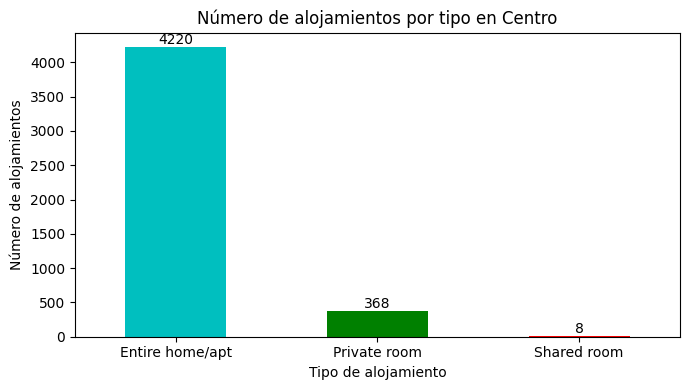

In [24]:
conteo_centro = df_limpio[df_limpio["neighbourhood"] == "Centro"]["room_type"].value_counts()

plt.figure(figsize=(7,4))
conteo_centro.plot(kind="bar", color=["c", "g", "r", "b"])

plt.title("Número de alojamientos por tipo en Centro")
plt.ylabel("Número de alojamientos")
plt.xlabel("Tipo de alojamiento")
plt.xticks(rotation=0)

# Añadir etiquetas encima de cada barra
for i, valor in enumerate(conteo_centro):
    plt.text(i, valor + 1, str(valor), ha='center', va='bottom', fontsize=10)

    
plt.tight_layout()
plt.show()

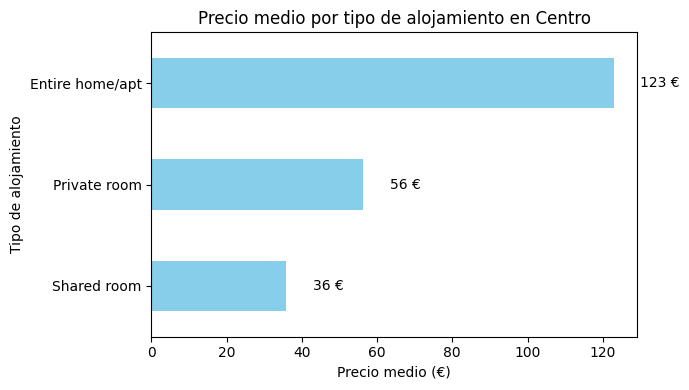

In [22]:
media_centro = df_limpio[df_limpio["neighbourhood"] == "Centro"].groupby("room_type")["price"].mean().sort_values()

plt.figure(figsize=(7,4))
ax = media_centro.plot(kind="barh", color="skyblue")

# Etiquetas encima de cada barra
for i, valor in enumerate(media_centro):
    plt.text(valor + 7, i, f"{valor:.0f} €", va='center')

plt.title("Precio medio por tipo de alojamiento en Centro")
plt.xlabel("Precio medio (€)")
plt.ylabel("Tipo de alojamiento")
plt.tight_layout()
plt.show()

In [33]:
# Tabla de alojamientos por barrio y tipo
tabla = df_limpio.groupby(['neighbourhood', 'room_type']).size().unstack(fill_value=0)

# Calcular el precio medio por barrio (redondeado a 2 decimales)
precio_medio = df_limpio.groupby('neighbourhood')['price'].mean().round(2)

# Añadir la columna del precio medio al inicio
tabla.insert(0, 'precio_medio', precio_medio)

# Añadir columna con el total de alojamientos
columnas_alojamientos = ['Entire home/apt', 'Hotel room', 'Private room', 'Shared room']
tabla['total_alojamientos'] = tabla[columnas_alojamientos].sum(axis=1)

# Ordenar la tabla por precio medio de forma descendente
tabla = tabla.sort_values(by='precio_medio', ascending=False)

tabla



room_type,precio_medio,Entire home/apt,Hotel room,Private room,Shared room,total_alojamientos
neighbourhood,,,,,,
Campanillas,204.00,12,0,1,0,13
Churriana,161.30,87,0,17,0,104
Palma-Palmilla,141.65,103,0,20,0,123
Puerto de la Torre,139.39,22,0,6,0,28
Este,137.90,627,0,44,0,671
Centro,117.46,4220,0,368,8,4596
Ciudad Jardin,113.13,39,0,13,0,52
Carretera de Cadiz,104.08,524,0,124,5,653
Cruz De Humilladero,94.25,214,1,74,0,289


In [38]:
# 1. Proporción por tipo de alojamiento dentro de cada barrio
proporcion_por_alojamiento = pd.crosstab(
    df_limpio['neighbourhood'],
    df_limpio['room_type'],
    normalize='index'
) * 100

# 2. Redondear proporciones
proporcion_por_alojamiento = proporcion_por_alojamiento.round(2)

# 3. Calcular el precio medio por barrio
precio_medio = df_limpio.groupby('neighbourhood')['price'].mean().round(2)

# 4. Añadir el precio medio como columna
proporcion_por_alojamiento['precio_medio'] = precio_medio

# 5. Ordenar por precio medio de forma descendente
proporcion_por_alojamiento = proporcion_por_alojamiento.sort_values(
    by='precio_medio',
    ascending=False
)

proporcion_por_alojamiento


room_type,Entire home/apt,Hotel room,Private room,Shared room,precio_medio
neighbourhood,,,,,
Campanillas,92.31,0.00,7.69,0.00,204.00
Churriana,83.65,0.00,16.35,0.00,161.30
Palma-Palmilla,83.74,0.00,16.26,0.00,141.65
Puerto de la Torre,78.57,0.00,21.43,0.00,139.39
Este,93.44,0.00,6.56,0.00,137.90
Centro,91.82,0.00,8.01,0.17,117.46
Ciudad Jardin,75.00,0.00,25.00,0.00,113.13
Carretera de Cadiz,80.25,0.00,18.99,0.77,104.08
Cruz De Humilladero,74.05,0.35,25.61,0.00,94.25


## Conclusión final hipótesis 1: por qué el Centro no es la zona más cara

Aunque el Centro es el barrio con mayor demanda turística y el que concentra el mayor número de alojamientos, los datos muestran que **no es la zona más cara**. Esto se explica por varios factores estructurales del mercado:

### 1. Exceso de oferta en el Centro
El Centro tiene más de 4.000 alojamientos, muy por encima del resto de barrios.  
Esta enorme oferta genera una fuerte competencia entre hosts, lo que tiende a **moderar los precios**.

**Alta oferta - alta competencia - precios más ajustados.**

### 2. Mezcla de tipos de alojamiento más económicos
En el Centro predominan:
- 4220 estudios completos con una media de 123 €.
- 368 habitaciones privadas con una media de 56 €.
- 8 habitaciones compartidas con una media de 36 €.

Y el análisis demuestra que **el tipo de alojamiento es el factor que más determina el precio**.  

### 3. La disponibilidad no influye en el precio
La correlación entre disponibilidad y precio es prácticamente cero.  
Esto significa que, aunque el Centro tenga mucha rotación y demanda, **la disponibilidad no empuja los precios hacia arriba**.

### 4. Los barrios más caros tienen menos oferta y alojamientos más grandes
Barrios como Campanillas, Churriana, Este o Puerto de la Torre tienen:
- menos alojamientos,  
- viviendas más grandes,  
- demanda más específica (playa, aeropuerto, PTA, zonas residenciales).

Esto eleva el precio medio de forma natural.

### 5. El Centro es un mercado saturado y maduro
La saturación turística del Centro hace que los precios estén más estabilizados.  
Los hosts ajustan tarifas para mantener ocupación en un entorno muy competitivo.

---

### Conclusión final
**El Centro no es el barrio más caro porque la enorme oferta y la alta competencia mantienen los precios moderados, mientras que los barrios más caros tienen menos alojamientos, viviendas más grandes y una demanda más específica que eleva el precio medio.**